#Effect of Feature Selection on Machine Learning Performance

## Introduction

Machine learning models do not always benefit from using every available feature.

Some features contain useful information, while others may contribute little to prediction or even introduce unnecessary complexity.

The objective of this experiment is to investigate how selecting different sets of features affects the performance of a Logistic Regression classifier using the Titanic dataset.

## Import Libraries

The following libraries are required for data preprocessing, model training, evaluation, and visualization.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

import matplotlib.pyplot as plt

## Load Dataset

The Titanic dataset is loaded into a pandas DataFrame and will be used throughout the experiment.

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

## Data Preparation

Before evaluating feature selection, the dataset is preprocessed.

Missing values are filled, categorical variables are converted into numerical variables using one-hot encoding, and unnecessary columns are removed.

This preprocessing ensures that all feature sets are compared under identical conditions.

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies( df, columns=["Sex", "Embarked"],drop_first=True)

df = df.drop(columns=[ "PassengerId", "Name", "Ticket", "Cabin"])

## Create Feature Sets

Different feature sets are created to evaluate how the number and type of input variables influence model performance.

Three feature sets will be compared:

- Basic Features
- Extended Features
- All Available Features

In [ ]:
basic_features = ["Pclass", "Age","Sex_male"]

extended_features = [ "Pclass", "Age", "Sex_male", "Fare", "SibSp","Parch"]

all_features = [column for column in df.columns if column != "Survived"]

## Evaluate Different Feature Sets

Each feature set is evaluated separately using the same Logistic Regression model.

The same train-test split, random seed, and model parameters are used for every experiment to ensure a fair comparison.

Performance is measured using Accuracy, Precision, Recall, F1-score, and the confusion matrix.

In [ ]:
def evaluate_features(feature_list):

    X = df[feature_list]
    y = df["Survived"]

    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

    model = LogisticRegression( max_iter=1000, random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {"Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp}

## Evaluate Each Feature Set

The Logistic Regression model is trained and evaluated using each feature set separately.

The results are stored for later comparison.

In [ ]:
results = {}

results["Basic Features"] = evaluate_features(basic_features)

results["Extended Features"] = evaluate_features(extended_features)

results["All Features"] = evaluate_features(all_features)

## Create Comparison Table

The evaluation results are converted into a pandas DataFrame to simplify comparison between different feature sets.

In [ ]:
comparison = pd.DataFrame(results).T

comparison = comparison.round(3)

comparison
comparison.to_csv("features_data_results.csv", index=True)

## Analysis of Results

The comparison shows that all three feature sets achieved the same overall Accuracy (0.810), indicating that simply adding more features did not improve the overall prediction rate.

The Extended Feature Set achieved the highest Precision (0.803), meaning it produced the fewest false positive predictions. However, its Recall decreased slightly to 0.716, indicating that fewer positive cases were correctly identified.

The All Feature Set achieved the highest Recall (0.743) and F1-score (0.764), demonstrating the best balance between Precision and Recall. This suggests that including all available informative features slightly improves the model's ability to identify positive cases.

The confusion matrices also support these observations. While the Extended Feature Set reduced false positive predictions, the All Feature Set correctly identified the largest number of positive cases (55), resulting in the highest Recall.

## Conclusion

This experiment demonstrates that feature selection influences different evaluation metrics in different ways.

Using a smaller number of carefully selected features can improve Precision, while using all available informative features provides better Recall and the highest overall F1-score.

The results show that selecting the optimal feature set is an important step in machine learning and should be based on the specific objective of the model rather than simply maximizing the number of input variables.

## Accuracy Comparison

The following graph compares the Accuracy of the Logistic Regression model using different feature sets.

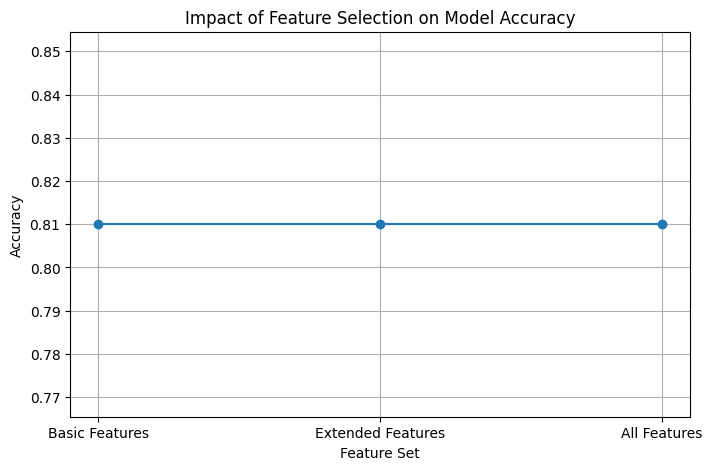

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(comparison.index, comparison["Accuracy"],marker="o")

plt.xlabel("Feature Set")
plt.ylabel("Accuracy")
plt.title("Impact of Feature Selection on Model Accuracy")

plt.grid(True)

plt.savefig("accuracy_feature_selection.png")

plt.show()

## F1-score Comparison

The following graph compares the F1-score obtained using different feature sets.

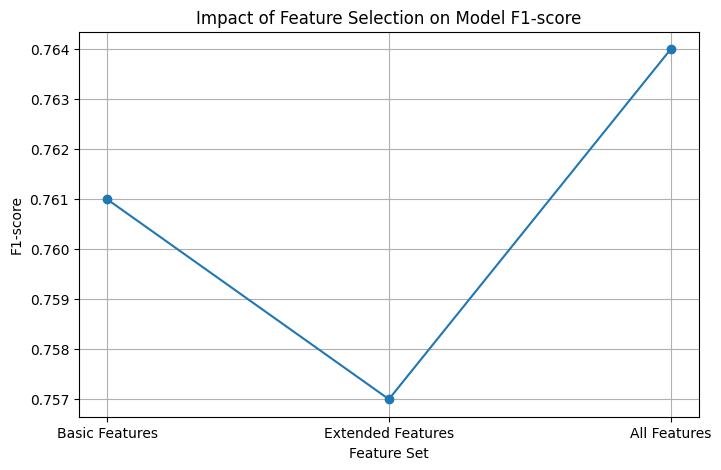

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    comparison.index,
    comparison["F1-score"],
    marker="o"
)

plt.xlabel("Feature Set")
plt.ylabel("F1-score")
plt.title("Impact of Feature Selection on Model F1-score")

plt.grid(True)

plt.savefig("f1_feature_selection.png")

plt.show()